# 01 — Data exploration (v1)

Giai đoạn 1 (`docs/PLAN.md`) — spec: `docs/specs/g1-data.md`.

Mục tiêu: tải dataset v1 (5 lớp, bbox có sẵn từ Roboflow "YOLO YOGA Dataset"),
xác nhận cấu trúc, đếm ảnh/lớp/split, kiểm tra imbalance, sanity-check bbox
bằng mắt, và chốt augmentation dùng cho train ở Giai đoạn 2.

**Chạy trên Colab** (cần `ROBOFLOW_API_KEY` — Colab Secret từ T0.3, hoặc
biến môi trường nếu chạy local sau khi có `.env` từ T0.2).

## Setup — mount Drive + cd vào repo

Mọi cell dưới đây dùng đường dẫn tương đối (`scripts/...`, `data/...`) nên
**bắt buộc** working directory phải là gốc repo trước khi chạy tiếp. Trên
Colab, cwd mặc định là `/content`, không phải repo đã clone ở T0.4 — cell
này mount Drive rồi `cd` vào đúng chỗ. Sửa `REPO_DIR_NAME` nếu bạn đặt tên
thư mục clone khác `computer-vision-project`.

In [1]:
import os

REPO_DIR_NAME = "computer-vision-project"  # đổi nếu bạn git clone ra tên thư mục khác

try:
    from google.colab import drive

    drive.mount("/content/drive")
    drive_path = f"/content/drive/MyDrive/{REPO_DIR_NAME}"
    if not os.path.isdir(drive_path):
        raise FileNotFoundError(
            f"{drive_path} không tồn tại — kiểm tra lại bạn đã `git clone` repo vào "
            "đúng chỗ trong Drive chưa (T0.4), hoặc sửa REPO_DIR_NAME ở trên cho khớp."
        )
    os.chdir(drive_path)
except ImportError:
    pass  # không chạy trên Colab (vd Jupyter local) — giả định cwd đã là repo root

print("cwd:", os.getcwd())
assert os.path.isdir("scripts") and os.path.isdir("data"), (
    "Chưa đứng ở repo root — không thấy scripts/ và data/ ở cwd hiện tại."
)

Mounted at /content/drive
cwd: /content/drive/MyDrive/computer-vision-project


## Cài dependencies

**Mỗi phiên Colab mới (runtime restart) đều mất hết package đã cài** — dù
T0.5 đã `pip install` một lần trước đó, phiên hiện tại vẫn cần cài lại.
Cell này idempotent — chạy lại nhiều lần không sao (pip tự bỏ qua package
đã có đúng version).

In [2]:
!pip install -q -r requirements.txt
import roboflow  # noqa: F401 — sanity-check ngay, fail sớm nếu install có vấn đề

print("roboflow import OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 110.3 MB/s eta 0:00

## T1.1 — Tải data

Dùng `scripts/download_data.sh` (đã có sẵn, không duplicate logic Roboflow
API ở đây). Cell dưới lo phần lấy `ROBOFLOW_API_KEY` đúng chỗ trước khi gọi
script — ưu tiên Colab Secret nếu đang chạy trên Colab, fallback về env var
đã có sẵn (vd từ `.env` khi chạy local).

In [3]:
import os

try:
    from google.colab import userdata  # only exists on Colab
    os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")
    print("ROBOFLOW_API_KEY loaded from Colab Secret.")
except ImportError:
    if "ROBOFLOW_API_KEY" in os.environ:
        print("ROBOFLOW_API_KEY already set in environment (local run).")
    else:
        raise RuntimeError(
            "ROBOFLOW_API_KEY not set. On Colab: add it as a Secret (T0.3). "
            "Locally: copy .env.example -> .env, fill it in, then export it "
            "into this process before running this cell (T0.2)."
        )

ROBOFLOW_API_KEY loaded from Colab Secret.


In [4]:
!bash scripts/download_data.sh

loading Roboflow workspace...
loading Roboflow project...

Extracting Dataset Version Zip to data/raw/yoga_v1 in yolov8:: 100% 2038/2038 [00:24<00:00, 83.53it/s]
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Downloaded to /content/drive/MyDrive/computer-vision-project/data/raw/yoga_v1


In [5]:
from pathlib import Path

DATA_ROOT = Path("data/raw/yoga_v1")
assert (DATA_ROOT / "data.yaml").exists(), (
    f"{DATA_ROOT / 'data.yaml'} not found — check the download cell above ran without error."
)
print("Data root OK:", DATA_ROOT.resolve())

Data root OK: /content/drive/MyDrive/computer-vision-project/data/raw/yoga_v1


## T1.2 — Số lớp + số ảnh mỗi split

In [6]:
import yaml

with open(DATA_ROOT / "data.yaml") as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml["names"]
print(f"{len(class_names)} lớp: {class_names}")

splits = ["train", "valid", "test"]
split_counts = {}
for split in splits:
    images_dir = DATA_ROOT / split / "images"
    n = len(list(images_dir.glob("*"))) if images_dir.exists() else 0
    split_counts[split] = n
    print(f"{split:6s}: {n} ảnh")
print("Tổng:", sum(split_counts.values()))

5 lớp: ['yoga-pose bridge', 'yoga-pose downward', 'yoga-pose plank', 'yoga-pose shoulderstand', 'yoga-pose tree']
train : 709 ảnh
valid : 203 ảnh
test  : 101 ảnh
Tổng: 1013


## T1.3 — Phân bố ảnh theo lớp (kiểm tra imbalance)

Đếm số lần mỗi `class_id` xuất hiện trong các file label `.txt`
(YOLO format: mỗi dòng = `class_id x_center y_center w h`), gộp cả 3 split.

Counter({'yoga-pose downward': 248, 'yoga-pose tree': 216, 'yoga-pose shoulderstand': 206, 'yoga-pose plank': 195, 'yoga-pose bridge': 158})


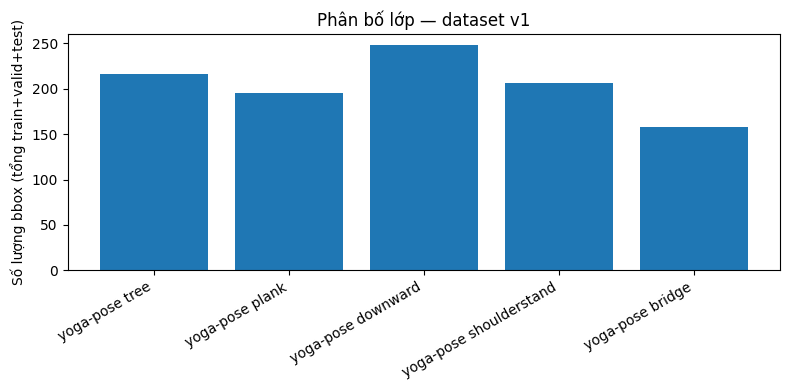

In [7]:
from collections import Counter

import matplotlib.pyplot as plt

class_counts = Counter()
for split in splits:
    labels_dir = DATA_ROOT / split / "labels"
    if not labels_dir.exists():
        continue
    for label_file in labels_dir.glob("*.txt"):
        for line in label_file.read_text().splitlines():
            if not line.strip():
                continue
            class_id = int(line.split()[0])
            class_counts[class_names[class_id]] += 1

print(class_counts)

plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.ylabel("Số lượng bbox (tổng train+valid+test)")
plt.title("Phân bố lớp — dataset v1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Nhận xét (điền sau khi chạy):** _lớp nào lệch hẳn so với các lớp còn lại,
hay tương đối cân bằng?_

## T1.4 — Sanity-check bbox

Vẽ bbox (convert YOLO normalized xywh → pixel xyxy) lên 2-3 ảnh mẫu mỗi lớp
để xác nhận nhãn khớp đúng vị trí học viên trong ảnh.

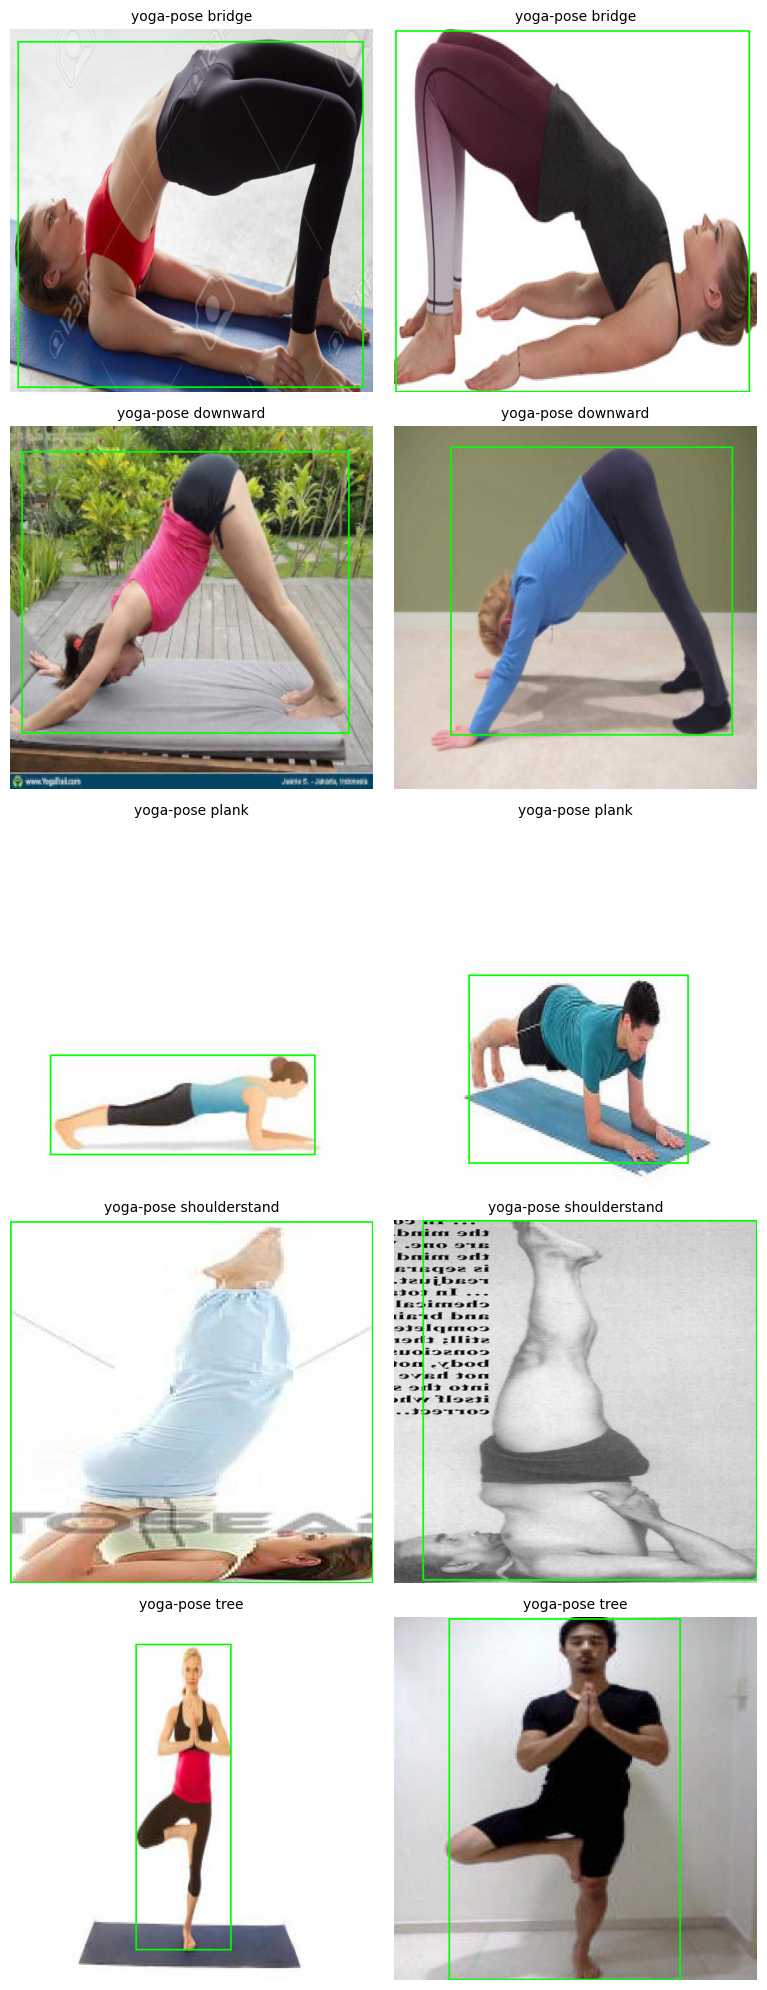

In [8]:
import random

from PIL import Image, ImageDraw

SAMPLES_PER_CLASS = 2
random.seed(42)


def yolo_to_xyxy(cx, cy, w, h, img_w, img_h):
    x1 = (cx - w / 2) * img_w
    y1 = (cy - h / 2) * img_h
    x2 = (cx + w / 2) * img_w
    y2 = (cy + h / 2) * img_h
    return x1, y1, x2, y2


# Index label files by class present, pooled across splits.
by_class: dict[int, list[Path]] = {i: [] for i in range(len(class_names))}
for split in splits:
    labels_dir = DATA_ROOT / split / "labels"
    if not labels_dir.exists():
        continue
    for label_file in labels_dir.glob("*.txt"):
        lines = [l for l in label_file.read_text().splitlines() if l.strip()]
        if not lines:
            continue
        first_class = int(lines[0].split()[0])
        by_class[first_class].append(label_file)

fig, axes = plt.subplots(
    len(class_names), SAMPLES_PER_CLASS, figsize=(4 * SAMPLES_PER_CLASS, 4 * len(class_names))
)
for class_id, class_name in enumerate(class_names):
    candidates = by_class.get(class_id, [])
    picks = random.sample(candidates, min(SAMPLES_PER_CLASS, len(candidates)))
    for col in range(SAMPLES_PER_CLASS):
        ax = axes[class_id, col] if len(class_names) > 1 else axes[col]
        ax.axis("off")
        if col >= len(picks):
            continue
        label_file = picks[col]
        image_file = label_file.parents[1] / "images" / (label_file.stem + ".jpg")
        if not image_file.exists():
            # some Roboflow exports use .png
            image_file = image_file.with_suffix(".png")
        img = Image.open(image_file).convert("RGB")
        draw = ImageDraw.Draw(img)
        for line in label_file.read_text().splitlines():
            if not line.strip():
                continue
            cid, cx, cy, w, h = (float(v) for v in line.split())
            box = yolo_to_xyxy(cx, cy, w, h, img.width, img.height)
            draw.rectangle(box, outline="lime", width=3)
        ax.imshow(img)
        ax.set_title(class_name, fontsize=10)
plt.tight_layout()
plt.show()

**Nhận xét (điền sau khi chạy):** _nhãn có khớp đúng vị trí học viên không,
có ảnh nào bbox lệch/sai không?_

## T1.5 — Chốt augmentation

Quyết định (xem lý do đầy đủ trong `docs/specs/g1-data.md` T1.5 và
`CLAUDE.md`):

- `flipud=0.0` — **tắt**. Lật dọc làm tư thế yoga vô nghĩa (người lộn ngược).
- `fliplr=0.5` — **giữ**. Hầu hết tư thế yoga đối xứng trái/phải, an toàn.
- `degrees=10` — **giới hạn thấp**. Xoay mạnh vừa làm sai lệch bbox vừa làm
  sai lệch góc khớp có ý nghĩa cho lớp rule-based (`angle_rules.py`) sau này.

Giá trị `degrees` có thể điều chỉnh sau khi nhìn ảnh sanity-check ở T1.4 —
nếu ảnh gốc đã đa dạng góc chụp thì có thể giảm thêm; nếu ảnh khá đồng nhất
về góc thì giữ nguyên. Các giá trị này sẽ được truyền vào `train()` trong
`src/models/train.py` ở Giai đoạn 2.